# Feature Binner

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/feature-binner/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/feature-binner/demo.ipynb)

> Binning a feature and computing its Information Value takes twenty lines. Knowing whether
> the IV you just printed means anything is the actual job - and the conventional
> 0.02 / 0.1 / 0.3 thresholds cannot tell you, because **IV is not comparable across bin counts**.

**What this covers**

1. A scorecard dataset with the four awkward cases planted in it
2. Missing values and sentinel codes - why imputing them destroys real signal
3. Smoothed WOE, and why the smoothing constant has to be a declared parameter
4. Monotonicity, and reading its cost as a diagnostic
5. **The main event**: raw IV on a column that is literally `rng.normal()`
6. The permutation null - the reference the IV bands are missing
7. Frozen cut points, holdout counts, and PSI
8. The audit table, and what it drops
9. Try your own feature

*Fully offline - the dataset is generated, no real credit data, numpy only.*

## 1. The dataset

A small application scorecard: 12,000 applications, an 11% default rate. Four awkward cases
are planted deliberately, because they are the four that show up in every real credit file:

| Feature | What is planted |
|---|---|
| `utilization` | genuinely monotone, strongest predictor |
| `income` | genuinely monotone, moderate |
| `age` | genuinely **non-monotone** - young and old are both riskier |
| `months_employed` | 18% missing, **and the missingness itself is predictive** (thin file) |
| `n_inquiries` | `-999` sentinel for 'no bureau record', which is the riskiest group on the book |
| `noise` | `rng.normal()`. No relationship to anything. |

Here is the whole engine - numpy only, no sklearn.

In [1]:
"""Monotone optimal binning with WOE/IV - and an IV number you can defend.

The mechanics of binning are easy. The reason binned scorecards ship broken features is
that the standard workflow measures a feature's strength on the same rows that chose its
cut points, so the strength is partly the fit.

Five mechanisms:

1. SEPARATION - missing values and sentinel codes (-999, 0-as-not-applicable) get their own
   bins and are never merged into a numeric range. Imputing them to the median merges two
   populations and destroys a signal that is often real (a thin credit file defaults
   differently).
2. SMOOTHED WOE - an empty or near-empty bin sends log-odds to infinity. Additive smoothing
   fixes the arithmetic, but the constant changes IV, so it is a declared parameter rather
   than a hidden 0.5.
3. CONSTRAINED MERGE - greedy adjacent merging under a minimum bin population and a minimum
   event count, choosing the merge that costs the least information at each step.
4. MONOTONICITY - scorecards need monotone WOE to survive review. Enforcing it costs IV.
   The size of that cost is diagnostic: small means the wiggle was noise, large means the
   relationship is genuinely non-monotone and you are destroying signal to get a shape.
5. HONEST IV - fit the cut points on train, recompute IV on holdout with those cut points
   frozen. The gap is the optimism. On pure noise it is nearly the whole number.

Plus PSI, because a bin scheme fit on last year's population drifts.

No database, no network, no sklearn. numpy only.
"""

from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np

MISSING = "missing"
SPECIAL = "special"
NUMERIC = "numeric"


# --------------------------------------------------------------------------------------
# Bins
# --------------------------------------------------------------------------------------


@dataclass
class Bin:
    """One bin. `lo`/`hi` are the numeric edges; ignored for missing/special bins."""

    kind: str  # NUMERIC | MISSING | SPECIAL
    lo: float = -math.inf
    hi: float = math.inf
    special_value: Optional[float] = None
    n: int = 0
    events: int = 0

    @property
    def nonevents(self) -> int:
        return self.n - self.events

    @property
    def event_rate(self) -> float:
        return self.events / self.n if self.n else float("nan")

    @property
    def label(self) -> str:
        if self.kind == MISSING:
            return "missing"
        if self.kind == SPECIAL:
            return f"= {self.special_value:g} (special)"
        lo = "-inf" if self.lo == -math.inf else f"{self.lo:,.4g}"
        hi = "inf" if self.hi == math.inf else f"{self.hi:,.4g}"
        return f"({lo}, {hi}]"


@dataclass
class Binning:
    """A fitted scheme. Cut points are frozen here; applying them elsewhere is what makes
    the holdout IV honest."""

    feature: str
    bins: List[Bin]
    smoothing: float
    monotone: str  # "none" | "increasing" | "decreasing"
    total_events: int = 0
    total_nonevents: int = 0
    notes: List[str] = field(default_factory=list)

    # -- WOE / IV ----------------------------------------------------------------------

    def woe(self, b: Bin) -> float:
        """Smoothed log-odds of this bin against the population.

        Additive smoothing on both counts. Without it a zero-event bin returns -inf and
        every downstream sum becomes nan; with it, a 3-event bin stops pretending to be
        a 300-event bin.
        """
        a = self.smoothing
        p_event = (b.events + a) / (self.total_events + 2 * a)
        p_nonevent = (b.nonevents + a) / (self.total_nonevents + 2 * a)
        return math.log(p_event / p_nonevent)

    def share_event(self, b: Bin) -> float:
        a = self.smoothing
        return (b.events + a) / (self.total_events + 2 * a)

    def share_nonevent(self, b: Bin) -> float:
        a = self.smoothing
        return (b.nonevents + a) / (self.total_nonevents + 2 * a)

    @property
    def iv(self) -> float:
        return sum(
            (self.share_event(b) - self.share_nonevent(b)) * self.woe(b) for b in self.bins
        )

    @property
    def numeric_bins(self) -> List[Bin]:
        return [b for b in self.bins if b.kind == NUMERIC]

    @property
    def cuts(self) -> List[float]:
        """Interior cut points - the only thing that transfers to new data."""
        return [b.hi for b in self.numeric_bins[:-1]]

    @property
    def specials(self) -> List[float]:
        return [b.special_value for b in self.bins if b.kind == SPECIAL]

    def is_monotone(self, tol: float = 1e-12) -> Optional[str]:
        """Direction of monotone WOE across the numeric bins, or None if it wobbles.

        Missing and special bins are excluded by design: they are not on the numeric
        scale, so requiring them to sit in order is meaningless.
        """
        woes = [self.woe(b) for b in self.numeric_bins]
        if len(woes) < 2:
            return "increasing"
        diffs = [b - a for a, b in zip(woes, woes[1:])]
        if all(d >= -tol for d in diffs):
            return "increasing"
        if all(d <= tol for d in diffs):
            return "decreasing"
        return None

    def table(self) -> List[Dict[str, object]]:
        total = sum(b.n for b in self.bins)
        rows = []
        for b in self.bins:
            rows.append(
                {
                    "bin": b.label,
                    "kind": b.kind,
                    "n": b.n,
                    "share": b.n / total if total else float("nan"),
                    "events": b.events,
                    "event_rate": b.event_rate,
                    "woe": self.woe(b),
                    "iv_part": (self.share_event(b) - self.share_nonevent(b)) * self.woe(b),
                }
            )
        return rows

    # -- transform ---------------------------------------------------------------------

    def bin_index(self, value: float) -> int:
        if value is None or (isinstance(value, float) and math.isnan(value)):
            for i, b in enumerate(self.bins):
                if b.kind == MISSING:
                    return i
            return -1
        for i, b in enumerate(self.bins):
            if b.kind == SPECIAL and b.special_value == value:
                return i
        for i, b in enumerate(self.bins):
            if b.kind == NUMERIC and b.lo < value <= b.hi:
                return i
        return -1

    def transform(self, x: np.ndarray) -> np.ndarray:
        """Replace raw values with the WOE of their bin. This is what feeds the model."""
        woes = np.array([self.woe(b) for b in self.bins])
        idx = np.array([self.bin_index(v) for v in x])
        out = np.zeros(len(x))
        known = idx >= 0
        out[known] = woes[idx[known]]
        return out


# --------------------------------------------------------------------------------------
# Fitting
# --------------------------------------------------------------------------------------


def _assign(
    x: np.ndarray, y: np.ndarray, edges: Sequence[float], specials: Sequence[float]
) -> Tuple[List[Bin], List[Bin], List[Bin]]:
    """Split rows into numeric prebins, one missing bin, and one bin per special value."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=int)

    is_missing = np.isnan(x)
    is_special = np.zeros(len(x), dtype=bool)
    for value in specials:
        is_special |= x == value

    missing_bins: List[Bin] = []
    if is_missing.any():
        missing_bins.append(
            Bin(MISSING, n=int(is_missing.sum()), events=int(y[is_missing].sum()))
        )

    special_bins: List[Bin] = []
    for value in specials:
        mask = x == value
        if mask.any():
            special_bins.append(
                Bin(SPECIAL, special_value=value, n=int(mask.sum()), events=int(y[mask].sum()))
            )

    keep = ~(is_missing | is_special)
    xs, ys = x[keep], y[keep]

    numeric_bins: List[Bin] = []
    lo = -math.inf
    for hi in list(edges) + [math.inf]:
        mask = (xs > lo) & (xs <= hi)
        numeric_bins.append(Bin(NUMERIC, lo=lo, hi=hi, n=int(mask.sum()), events=int(ys[mask].sum())))
        lo = hi
    return numeric_bins, missing_bins, special_bins


def _iv_of(bins: Sequence[Bin], smoothing: float) -> float:
    total_e = sum(b.events for b in bins)
    total_ne = sum(b.nonevents for b in bins)
    if total_e == 0 or total_ne == 0:
        return 0.0
    out = 0.0
    for b in bins:
        pe = (b.events + smoothing) / (total_e + 2 * smoothing)
        pne = (b.nonevents + smoothing) / (total_ne + 2 * smoothing)
        out += (pe - pne) * math.log(pe / pne)
    return out


def _merge(bins: List[Bin], i: int) -> List[Bin]:
    """Merge bin i with bin i+1."""
    a, b = bins[i], bins[i + 1]
    merged = Bin(NUMERIC, lo=a.lo, hi=b.hi, n=a.n + b.n, events=a.events + b.events)
    return bins[:i] + [merged] + bins[i + 2 :]


def _cheapest_merge(bins: List[Bin], smoothing: float) -> int:
    """Index of the adjacent pair whose merge loses the least information."""
    best, best_iv = 0, -math.inf
    for i in range(len(bins) - 1):
        iv = _iv_of(_merge(bins, i), smoothing)
        if iv > best_iv:
            best, best_iv = i, iv
    return best


def _woe_seq(bins: Sequence[Bin], smoothing: float) -> List[float]:
    total_e = sum(b.events for b in bins)
    total_ne = sum(b.nonevents for b in bins)
    out = []
    for b in bins:
        pe = (b.events + smoothing) / (total_e + 2 * smoothing)
        pne = (b.nonevents + smoothing) / (total_ne + 2 * smoothing)
        out.append(math.log(pe / pne))
    return out


def fit(
    x: np.ndarray,
    y: np.ndarray,
    feature: str = "x",
    max_bins: int = 6,
    max_prebins: int = 20,
    min_bin_share: float = 0.05,
    min_bin_events: int = 20,
    smoothing: float = 0.5,
    monotone: bool = True,
    specials: Sequence[float] = (),
) -> Binning:
    """Fit a binning scheme.

    Order matters. Size constraints come before monotonicity, because a monotone sequence
    built out of 4-row bins is monotone noise.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=int)
    notes: List[str] = []

    finite = x[~np.isnan(x)]
    for value in specials:
        finite = finite[finite != value]
    if len(finite) == 0:
        raise ValueError(f"{feature}: no numeric values left after removing missing/specials")

    quantiles = np.linspace(0, 100, max_prebins + 1)[1:-1]
    edges = sorted(set(np.percentile(finite, quantiles).tolist()))

    numeric, missing_bins, special_bins = _assign(x, y, edges, specials)
    if missing_bins:
        notes.append(
            f"{missing_bins[0].n} missing rows kept as their own bin "
            f"(event rate {missing_bins[0].event_rate:.1%})"
        )
    for b in special_bins:
        notes.append(
            f"{b.n} rows at sentinel {b.special_value:g} kept out of the numeric scale "
            f"(event rate {b.event_rate:.1%})"
        )

    n_numeric = sum(b.n for b in numeric)
    min_n = max(1, int(min_bin_share * n_numeric))

    # Stage 1 - satisfy the size floors.
    guard = 0
    while len(numeric) > 1 and guard < 500:
        guard += 1
        weak = [
            i
            for i, b in enumerate(numeric)
            if b.n < min_n or b.events < min_bin_events or b.nonevents < min_bin_events
        ]
        if not weak:
            break
        i = weak[0]
        j = i - 1 if i == len(numeric) - 1 else i
        numeric = _merge(numeric, j)

    # Stage 2 - respect max_bins, giving up the least information each time.
    while len(numeric) > max_bins:
        numeric = _merge(numeric, _cheapest_merge(numeric, smoothing))

    iv_unconstrained = _iv_of(numeric + missing_bins + special_bins, smoothing)
    direction = "none"

    # Stage 3 - monotonicity, by merging adjacent violators.
    if monotone and len(numeric) > 2:
        woes = _woe_seq(numeric, smoothing)
        ups = sum(1 for a, b in zip(woes, woes[1:]) if b > a)
        downs = len(woes) - 1 - ups
        direction = "increasing" if ups >= downs else "decreasing"
        guard = 0
        while len(numeric) > 2 and guard < 500:
            guard += 1
            woes = _woe_seq(numeric, smoothing)
            diffs = [b - a for a, b in zip(woes, woes[1:])]
            violations = [
                i
                for i, d in enumerate(diffs)
                if (d < 0 if direction == "increasing" else d > 0)
            ]
            if not violations:
                break
            worst = max(violations, key=lambda i: abs(diffs[i]))
            numeric = _merge(numeric, worst)

    bins = numeric + missing_bins + special_bins
    result = Binning(
        feature=feature,
        bins=bins,
        smoothing=smoothing,
        monotone=direction if monotone else "none",
        total_events=int(sum(b.events for b in bins)),
        total_nonevents=int(sum(b.nonevents for b in bins)),
        notes=notes,
    )
    if monotone:
        cost = iv_unconstrained - result.iv
        share = (
            f" ({cost / iv_unconstrained:.0%} of the unconstrained {iv_unconstrained:.4f})"
            if iv_unconstrained > 1e-12
            else " (unconstrained IV was already zero)"
        )
        result.notes.append(f"monotone ({direction}) cost {cost:.4f} IV{share}")
    return result


def refit_counts(scheme: Binning, x: np.ndarray, y: np.ndarray) -> Binning:
    """Re-count a FROZEN scheme on new rows. Cut points do not move.

    This is the whole honesty mechanism: same bins, different data, recomputed IV.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=int)
    fresh = [
        Bin(b.kind, lo=b.lo, hi=b.hi, special_value=b.special_value) for b in scheme.bins
    ]
    for value, label in zip(x, y):
        idx = scheme.bin_index(value)
        if idx < 0:
            continue
        fresh[idx].n += 1
        fresh[idx].events += int(label)
    return Binning(
        feature=scheme.feature,
        bins=fresh,
        smoothing=scheme.smoothing,
        monotone=scheme.monotone,
        total_events=int(sum(b.events for b in fresh)),
        total_nonevents=int(sum(b.nonevents for b in fresh)),
        notes=["counts recomputed on held-out rows; cut points frozen"],
    )


def psi(reference: Binning, current: Binning) -> float:
    """Population Stability Index between two count sets over the same bins."""
    ref_total = sum(b.n for b in reference.bins) or 1
    cur_total = sum(b.n for b in current.bins) or 1
    out = 0.0
    for rb, cb in zip(reference.bins, current.bins):
        r = max(rb.n / ref_total, 1e-6)
        c = max(cb.n / cur_total, 1e-6)
        out += (c - r) * math.log(c / r)
    return out


def null_iv(
    x: np.ndarray,
    y: np.ndarray,
    n_permutations: int = 40,
    seed: int = 0,
    **kwargs: object,
) -> np.ndarray:
    """IV this binning procedure produces from a feature with NO relationship to the target.

    Shuffle the labels, refit with identical settings, record IV. Repeat.

    This is the reference the conventional 0.02 / 0.1 / 0.3 bands are missing. Those
    thresholds assume a fixed, modest number of bins. IV is not comparable across bin
    counts: more bins mechanically raise it, and additive smoothing on a near-empty bin
    manufactures a large positive IV contribution out of a count of zero. A permutation
    null absorbs both effects, because the null is measured through the same procedure.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=int)
    out = []
    for _ in range(n_permutations):
        try:
            out.append(fit(x, rng.permutation(y), **kwargs).iv)  # type: ignore[arg-type]
        except ValueError:
            continue
    return np.array(out)


SETTINGS_LADDER = (
    ("6 bins, 20-event floor", dict(max_bins=6, min_bin_events=20, min_bin_share=0.05)),
    ("10 bins, 5-event floor", dict(max_bins=10, min_bin_events=5, min_bin_share=0.01)),
    ("20 bins, 1-event floor", dict(max_bins=20, min_bin_events=1, min_bin_share=0.002)),
    (
        "20 bins, 1-event, no monotone",
        dict(max_bins=20, min_bin_events=1, min_bin_share=0.002, monotone=False),
    ),
)


def noise_screen(
    y: np.ndarray,
    n_columns: int = 12,
    n_permutations: int = 40,
    iv_threshold: float = 0.10,
    alpha: float = 0.05,
    seed: int = 99,
) -> List[Dict[str, object]]:
    """How many pure-noise columns each screening rule lets through, per settings ladder.

    Generates independent rng.normal() columns - guaranteed zero relationship to `y` - and
    screens each one two ways: by raw IV against the conventional threshold, and by the
    permutation p-value. Averaging over columns instead of showing one is deliberate; a
    single noise column can land anywhere in its own null distribution.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=int)
    columns = [rng.normal(0, 1, len(y)) for _ in range(n_columns)]
    out: List[Dict[str, object]] = []

    for label, kwargs in SETTINGS_LADDER:
        ivs, excesses, bins, passed_iv, passed_perm = [], [], [], 0, 0
        for i, x in enumerate(columns):
            scheme = fit(x, y, **kwargs)  # type: ignore[arg-type]
            nulls = null_iv(x, y, n_permutations=n_permutations, seed=i, **kwargs)
            p = (np.sum(nulls >= scheme.iv) + 1) / (len(nulls) + 1)
            ivs.append(scheme.iv)
            excesses.append(scheme.iv - float(np.median(nulls)))
            bins.append(len(scheme.bins))
            passed_iv += scheme.iv >= iv_threshold
            passed_perm += p <= alpha
        out.append(
            {
                "settings": label,
                "mean_bins": float(np.mean(bins)),
                "mean_iv": float(np.mean(ivs)),
                "mean_excess": float(np.mean(excesses)),
                "kept_by_iv": passed_iv / n_columns,
                "kept_by_permutation": passed_perm / n_columns,
            }
        )
    return out


def sparse_bin_warning(scheme: Binning, floor: int = 20) -> Optional[str]:
    """IV stops meaning anything once bins are this thin - it becomes a smoothing artifact."""
    thin = [b for b in scheme.bins if b.events < floor or b.nonevents < floor]
    if not thin:
        return None
    return (
        f"{len(thin)} of {len(scheme.bins)} bins hold fewer than {floor} events or non-events; "
        "their WOE is driven by the smoothing constant, not by the data"
    )


IV_BANDS = (
    (0.02, "unpredictive"),
    (0.10, "weak"),
    (0.30, "medium"),
    (0.50, "strong"),
    (math.inf, "suspiciously strong - check for leakage"),
)


def iv_band(value: float) -> str:
    for threshold, label in IV_BANDS:
        if value < threshold:
            return label
    return "unknown"


# --------------------------------------------------------------------------------------
# Honesty report
# --------------------------------------------------------------------------------------


@dataclass
class Audit:
    feature: str
    iv_train: float
    iv_holdout: float
    monotone_train: Optional[str]
    monotone_holdout: Optional[str]
    psi: float
    n_bins: int
    scheme: Binning
    holdout: Binning
    null: np.ndarray = field(default_factory=lambda: np.array([]))

    @property
    def optimism(self) -> float:
        return self.iv_train - self.iv_holdout

    @property
    def shrinkage(self) -> float:
        return self.optimism / self.iv_train if self.iv_train else 0.0

    @property
    def null_median(self) -> float:
        return float(np.median(self.null)) if len(self.null) else float("nan")

    @property
    def excess_iv(self) -> float:
        """IV above what this procedure produces from shuffled labels. The number to quote."""
        return self.iv_train - self.null_median if len(self.null) else float("nan")

    @property
    def p_value(self) -> float:
        """Fraction of permutations reaching the observed IV (add-one smoothed)."""
        if not len(self.null):
            return float("nan")
        return float((np.sum(self.null >= self.iv_train) + 1) / (len(self.null) + 1))

    @property
    def sparse_warning(self) -> Optional[str]:
        return sparse_bin_warning(self.scheme)

    @property
    def verdict(self) -> str:
        if len(self.null) and self.p_value > 0.05:
            return "DROP - a shuffled target scores this well"
        if self.iv_holdout < 0.02:
            return "DROP - no out-of-sample signal"
        if self.shrinkage > 0.5:
            return "SUSPECT - most of the in-sample IV did not survive"
        if self.sparse_warning:
            return "SUSPECT - IV is smoothing-driven, bins too thin"
        if self.psi > 0.25:
            return "REVIEW - population shifted (PSI > 0.25)"
        if self.monotone_holdout is None:
            return "REVIEW - monotone on train, wobbles on holdout"
        return "OK"


def audit(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_holdout: np.ndarray,
    y_holdout: np.ndarray,
    feature: str = "x",
    n_permutations: int = 40,
    **kwargs: object,
) -> Audit:
    """Fit on train, then judge three ways: against a holdout, against a permutation null,
    and against the bin-thinness floor. The raw in-sample IV is the least useful of them."""
    scheme = fit(x_train, y_train, feature=feature, **kwargs)  # type: ignore[arg-type]
    holdout = refit_counts(scheme, x_holdout, y_holdout)
    null = (
        null_iv(x_train, y_train, n_permutations=n_permutations, **kwargs)
        if n_permutations
        else np.array([])
    )
    return Audit(
        feature=feature,
        iv_train=scheme.iv,
        iv_holdout=holdout.iv,
        monotone_train=scheme.is_monotone(),
        monotone_holdout=holdout.is_monotone(),
        psi=psi(scheme, holdout),
        n_bins=len(scheme.bins),
        scheme=scheme,
        holdout=holdout,
        null=null,
    )


# --------------------------------------------------------------------------------------
# Deterministic credit-style dataset
# --------------------------------------------------------------------------------------

SENTINEL_NO_BUREAU = -999.0


def build_dataset(n: int = 12000, seed: int = 11) -> Dict[str, object]:
    """A small application-scorecard dataset with the four awkward cases planted.

    - utilization      : genuinely monotone, strong
    - income           : genuinely monotone, moderate
    - age              : genuinely NON-monotone (U-shaped) - monotonicity costs real signal
    - months_employed  : 18% missing, and missingness is predictive (thin file)
    - n_inquiries      : sentinel -999 for 'no bureau record', which is the riskiest group
    - noise            : pure noise, no relationship whatsoever
    """
    rng = np.random.default_rng(seed)

    utilization = np.clip(rng.beta(2.0, 3.0, n), 0.001, 0.999)
    income = np.exp(rng.normal(10.7, 0.45, n))
    age = rng.integers(19, 76, n).astype(float)
    months_employed = np.clip(rng.gamma(2.0, 30.0, n), 0, 480)
    n_inquiries = rng.poisson(1.4, n).astype(float)
    noise = rng.normal(0, 1, n)

    # Log-odds of default.
    logit = -2.9
    logit = logit + 2.6 * (utilization - 0.4)
    logit = logit - 0.9 * (np.log(income) - 10.7)
    logit = logit + 0.0016 * (age - 42.0) ** 2 - 0.35  # U-shaped: young and old are riskier
    logit = logit + 0.10 * np.minimum(n_inquiries, 6)

    # Thin file: no employment record on file, and that group is riskier.
    thin = rng.random(n) < 0.18
    months_employed[thin] = np.nan
    logit = logit + 0.75 * thin

    # No bureau record at all: sentinel, and the riskiest group on the book.
    no_bureau = rng.random(n) < 0.06
    n_inquiries[no_bureau] = SENTINEL_NO_BUREAU
    logit = logit + 1.15 * no_bureau

    # Employment length reduces risk where it is known.
    known = ~thin
    logit[known] = logit[known] - 0.004 * (months_employed[known] - 60.0)

    prob = 1.0 / (1.0 + np.exp(-logit))
    y = (rng.random(n) < prob).astype(int)

    # Time index, so drift is demonstrable: utilization creeps up in the later period.
    period = np.where(np.arange(n) < n // 2, "H1", "H2")
    late = period == "H2"
    utilization[late] = np.clip(utilization[late] + 0.10, 0.001, 0.999)

    features = {
        "utilization": utilization,
        "income": income,
        "age": age,
        "months_employed": months_employed,
        "n_inquiries": n_inquiries,
        "noise": noise,
    }
    specials = {"n_inquiries": (SENTINEL_NO_BUREAU,)}

    idx = rng.permutation(n)
    split = int(0.6 * n)
    train_idx, holdout_idx = idx[:split], idx[split:]

    return {
        "features": features,
        "y": y,
        "specials": specials,
        "period": period,
        "train_idx": train_idx,
        "holdout_idx": holdout_idx,
        "base_rate": float(y.mean()),
    }


# --------------------------------------------------------------------------------------
# Reporting
# --------------------------------------------------------------------------------------


def format_table(scheme: Binning) -> str:
    lines = [
        f"{'bin':<24} {'n':>6} {'share':>7} {'events':>7} {'rate':>7} {'WOE':>8} {'IV part':>8}"
    ]
    lines.append("-" * 72)
    for row in scheme.table():
        lines.append(
            f"{str(row['bin']):<24} {row['n']:>6} {row['share']:>6.1%} {row['events']:>7} "
            f"{row['event_rate']:>6.1%} {row['woe']:>8.3f} {row['iv_part']:>8.4f}"
        )
    lines.append("-" * 72)
    lines.append(f"{'IV':<24} {scheme.iv:>6.4f}  ({iv_band(scheme.iv)})")
    mono = scheme.is_monotone()
    lines.append(f"{'monotone':<24} {mono or 'NO - WOE wobbles'}")
    for note in scheme.notes:
        lines.append(f"  note: {note}")
    return "\n".join(lines)


def audit_report(audits: Sequence[Audit]) -> str:
    lines = [
        f"{'feature':<17} {'IV train':>9} {'IV null':>8} {'excess':>8} {'p':>6} "
        f"{'IV hold':>8} {'PSI':>6}  verdict"
    ]
    lines.append("-" * 104)
    for a in sorted(audits, key=lambda a: -a.excess_iv):
        lines.append(
            f"{a.feature:<17} {a.iv_train:>9.4f} {a.null_median:>8.4f} {a.excess_iv:>8.4f} "
            f"{a.p_value:>6.3f} {a.iv_holdout:>8.4f} {a.psi:>6.3f}  {a.verdict}"
        )
    lines.append("")
    lines.append("  IV null = median IV this same procedure gets from SHUFFLED labels.")
    lines.append("  excess  = IV train - IV null. Quote this, not IV train.")
    for a in audits:
        if a.sparse_warning:
            lines.append(f"  ! {a.feature}: {a.sparse_warning}")
    return "\n".join(lines)


In [2]:
data = build_dataset()
y = data["y"]
tr, ho = data["train_idx"], data["holdout_idx"]
F = data["features"]

print(f"applications      {len(y):,}")
print(f"default rate      {data['base_rate']:.2%}")
print(f"train / holdout   {len(tr):,} / {len(ho):,}")
print()
for name, values in F.items():
    n_missing = int(np.isnan(values).sum())
    n_special = int((values == SENTINEL_NO_BUREAU).sum())
    extra = []
    if n_missing:
        extra.append(f"{n_missing:,} missing")
    if n_special:
        extra.append(f"{n_special:,} at sentinel -999")
    print(f"  {name:<18} {' , '.join(extra) if extra else 'complete'}")

applications      12,000
default rate      10.96%
train / holdout   7,200 / 4,800

  utilization        complete
  income             complete
  age                complete
  months_employed    2,080 missing
  n_inquiries        700 at sentinel -999
  noise              complete


## 2. Missing and sentinel values are populations, not gaps

The reflex is `fillna(median)`. On a credit file that is a mistake twice over: it merges two
different populations into one bin, and it throws away a signal that is often stronger than
the numeric trend it is hiding.

In [3]:
me = fit(F["months_employed"][tr], y[tr], feature="months_employed")
print(format_table(me))

missing = [b for b in me.bins if b.kind == MISSING][0]
numeric_rate = sum(b.events for b in me.numeric_bins) / sum(b.n for b in me.numeric_bins)
print()
print(f"applicants with an employment record : {numeric_rate:.2%} default")
print(f"applicants with no record on file    : {missing.event_rate:.2%} default")
print(f"                                       WOE {me.woe(missing):+.3f}")
print("\nImputing that group to the median would have hidden it inside a middle bin.")

bin                           n   share  events    rate      WOE  IV part
------------------------------------------------------------------------
(-inf, 28.58]              1488  20.7%     170  11.4%    0.047   0.0005
(28.58, 54.64]             1784  24.8%     166   9.3%   -0.182   0.0076
(54.64, 98.64]             1785  24.8%     165   9.2%   -0.189   0.0082
(98.64, inf]                893  12.4%      68   7.6%   -0.397   0.0167
missing                    1250  17.4%     221  17.7%    0.556   0.0664
------------------------------------------------------------------------
IV                       0.0995  (weak)
monotone                 decreasing
  note: 1250 missing rows kept as their own bin (event rate 17.7%)
  note: monotone (decreasing) cost 0.0086 IV (8% of the unconstrained 0.1080)

applicants with an employment record : 9.56% default
applicants with no record on file    : 17.68% default
                                       WOE +0.556

Imputing that group to the median would 

Sentinel codes are the same problem wearing a number. `-999` is not a low inquiry count -
it means the bureau returned nothing at all, and here it is the single riskiest group.

Left on the numeric scale it sorts below zero, lands in the lowest bin, and corrupts the
monotonic story with a group that does not belong on the axis at all.

In [4]:
ni = fit(F["n_inquiries"][tr], y[tr], feature="n_inquiries", specials=(SENTINEL_NO_BUREAU,))
print(format_table(ni))

# Same feature, sentinel NOT declared - it gets treated as a real value of -999.
naive = fit(F["n_inquiries"][tr], y[tr], feature="n_inquiries")
print("\nWithout declaring the sentinel:")
print(format_table(naive))
print(f"\nIV {naive.iv:.4f} vs {ni.iv:.4f} declared - and the riskiest group is now buried")
print("inside the lowest bin, pulling its WOE up and flattening everything above it.")

bin                           n   share  events    rate      WOE  IV part
------------------------------------------------------------------------
(-inf, 0]                  1725  24.0%     140   8.1%   -0.331   0.0231
(0, 1]                     2284  31.7%     230  10.1%   -0.095   0.0028
(1, 2]                     1620  22.5%     173  10.7%   -0.029   0.0002
(2, inf]                   1149  16.0%     145  12.6%    0.160   0.0044
= -999 (special)            422   5.9%     102  24.2%    0.952   0.0758
------------------------------------------------------------------------
IV                       0.1062  (medium)
monotone                 increasing
  note: 422 rows at sentinel -999 kept out of the numeric scale (event rate 24.2%)
  note: monotone (increasing) cost 0.0006 IV (1% of the unconstrained 0.1067)

Without declaring the sentinel:
bin                           n   share  events    rate      WOE  IV part
------------------------------------------------------------------------
(

## 3. Smoothed WOE

WOE is a log-odds ratio, so a bin with zero events sends it to `-inf` and every downstream
sum to `nan`. Additive smoothing fixes the arithmetic. It does not fix the underlying
problem, and it is not free - the constant changes IV, so it belongs in the signature rather
than hardcoded at 0.5 somewhere inside.

In [5]:
x = np.concatenate([np.zeros(60), np.ones(60)])
y_sep = np.concatenate([np.zeros(60, dtype=int), np.ones(60, dtype=int)])

for s in (0.01, 0.5, 2.0):
    scheme = fit(x, y_sep, min_bin_events=0, min_bin_share=0.01, max_bins=2,
                 monotone=False, smoothing=s)
    woes = [round(scheme.woe(b), 3) for b in scheme.bins]
    print(f"smoothing={s:<5} IV={scheme.iv:>8.4f}  WOE={woes}")

print("\nSame data, same bins, three different IVs. Which is why the real fix is a floor:")
floored = fit(x, y_sep, min_bin_events=1, min_bin_share=0.01, max_bins=2, monotone=False)
print(f"with min_bin_events=1, the zero-event bin is merged away -> {len(floored.bins)} bin, IV {floored.iv:.4f}")

smoothing=0.01  IV= 17.3936  WOE=[-8.7, 8.7]
smoothing=0.5   IV=  9.4343  WOE=[-4.796, 4.796]
smoothing=2.0   IV=  6.4387  WOE=[-3.434, 3.434]

Same data, same bins, three different IVs. Which is why the real fix is a floor:
with min_bin_events=1, the zero-event bin is merged away -> 1 bin, IV 0.0000


## 4. Monotonicity, and reading its price

Scorecards want monotone WOE: risk should move one direction as the feature moves, or the
risk story does not survive a review committee. The binner enforces it by merging adjacent
violators.

Enforcing it always costs IV. **The size of the cost is the interesting part** - it tells you
what you just deleted.

In [6]:
print(f"{'feature':<18} {'free IV':>9} {'monotone IV':>12} {'cost':>8} {'cost %':>7}  reading")
print("-" * 86)
for name in ("utilization", "income", "months_employed", "age"):
    free = fit(F[name][tr], y[tr], feature=name, monotone=False)
    forced = fit(F[name][tr], y[tr], feature=name, monotone=True)
    cost = free.iv - forced.iv
    pct = cost / free.iv if free.iv else 0
    reading = "the wiggle was noise - take the shape" if pct < 0.15 else "DELETING REAL SIGNAL"
    print(f"{name:<18} {free.iv:>9.4f} {forced.iv:>12.4f} {cost:>8.4f} {pct:>6.0%}  {reading}")

feature              free IV  monotone IV     cost  cost %  reading
--------------------------------------------------------------------------------------
utilization           0.2238       0.2207   0.0031     1%  the wiggle was noise - take the shape
income                0.1657       0.1627   0.0029     2%  the wiggle was noise - take the shape
months_employed       0.1080       0.0995   0.0086     8%  the wiggle was noise - take the shape
age                   0.2391       0.1632   0.0759    32%  DELETING REAL SIGNAL


`age` costs 32%. That is not a wiggle being cleaned up - the U-shape is real, planted as
`0.0016 * (age - 42)**2` in the data generator. Young and old applicants are both riskier
than the middle.

Forcing monotonicity here buys a shape the committee likes by throwing away a third of the
feature's predictive power. The honest options are to split it into two features, or to keep
the non-monotone bins and defend them.

In [7]:
free_age = fit(F["age"][tr], y[tr], feature="age", monotone=False)
print(format_table(free_age))
print("\nEvent rate by bin - the U is visible:")
for b in free_age.numeric_bins:
    bar = "#" * int(b.event_rate * 260)
    print(f"  {b.label:<20} {b.event_rate:>6.2%}  {bar}")

bin                           n   share  events    rate      WOE  IV part
------------------------------------------------------------------------
(-inf, 24]                  795  11.0%     118  14.8%    0.349   0.0154
(24, 27]                    369   5.1%      34   9.2%   -0.182   0.0016
(27, 50]                   2871  39.9%     188   6.5%   -0.563   0.1015
(50, 59]                   1119  15.5%     108   9.7%   -0.140   0.0029
(59, 70]                   1419  19.7%     194  13.7%    0.252   0.0138
(70, inf]                   627   8.7%     148  23.6%    0.920   0.1039
------------------------------------------------------------------------
IV                       0.2391  (medium)
monotone                 NO - WOE wobbles

Event rate by bin - the U is visible:
  (-inf, 24]           14.84%  ######################################
  (24, 27]              9.21%  #######################
  (27, 50]              6.55%  #################
  (50, 59]              9.65%  ####################

## 5. The main event: IV on pure noise

`noise` is `rng.normal(0, 1, n)`. It appears nowhere in the data generator's logit. Its true
predictive power is exactly zero.

Bin it four ways and read the IV.

In [8]:
small = build_dataset(n=800, seed=3)
ys, ts = small["y"], small["train_idx"]
xs = small["features"]["noise"][ts]
print(f"480 training rows, one pure-noise column.\n")
print(f"  {'settings':<32} {'bins':>5} {'IV':>8}  band")
print("  " + "-" * 62)
for label, kw in SETTINGS_LADDER:
    scheme = fit(xs, ys[ts], **kw)
    print(f"  {label:<32} {len(scheme.bins):>5} {scheme.iv:>8.4f}  {iv_band(scheme.iv)}")

480 training rows, one pure-noise column.

  settings                          bins       IV  band
  --------------------------------------------------------------
  6 bins, 20-event floor               2   0.0748  weak
  10 bins, 5-event floor               3   0.1524  medium
  20 bins, 1-event floor               5   0.1491  medium
  20 bins, 1-event, no monotone       17   0.4988  strong


Read that last row again. A column of Gaussian noise scores **"strong predictor"** on the
conventional scale.

Nothing is broken. IV is a sum over bins of `(share_events - share_nonevents) * WOE`, and
every extra bin adds another non-negative term. More bins means more IV, always. Add
smoothing and a near-empty bin contributes a *large* positive term built out of a count of
zero.

So the 0.02 / 0.1 / 0.3 / 0.5 thresholds are not thresholds on predictive power. They are
thresholds on predictive power **at a particular bin count**, and nobody writes down which one.

In [9]:
# Where the IV actually comes from at the loosest setting.
loose = fit(xs, ys[ts], **dict(max_bins=20, min_bin_events=1, min_bin_share=0.002, monotone=False))
rows = sorted(loose.table(), key=lambda r: -r["iv_part"])[:6]
print(f"top IV contributors, {len(loose.bins)}-bin scheme on pure noise:\n")
print(f"  {'bin':<22} {'n':>5} {'events':>7} {'WOE':>8} {'IV part':>9}")
for r in rows:
    print(f"  {str(r['bin']):<22} {r['n']:>5} {r['events']:>7} {r['woe']:>8.3f} {r['iv_part']:>9.4f}")
print(f"\n{sparse_bin_warning(loose)}")

top IV contributors, 17-bin scheme on pure noise:

  bin                        n  events      WOE   IV part
  (-0.5598, -0.4471]        24       6    1.024    0.0790
  (0.0287, 0.1425]          24       6    1.024    0.0790
  (0.5208, 0.6867]          24       6    1.024    0.0790
  (-1.67, -1.07]            48       2   -0.853    0.0532
  (0.4039, 0.5208]          24       5    0.804    0.0453
  (-1.07, -0.6976]          48       3   -0.495    0.0205

17 of 17 bins hold fewer than 20 events or non-events; their WOE is driven by the smoothing constant, not by the data


## 6. The permutation null

If IV depends on the procedure, then measure the procedure. Shuffle the labels - destroying
any relationship while keeping the marginal distributions - refit with **identical** settings,
and record the IV. Repeat.

That distribution is what "no signal" looks like *through this binner*. Compare against it
instead of against a constant from a textbook.

In [10]:
kw = dict(max_bins=20, min_bin_events=1, min_bin_share=0.002, monotone=False)
observed = fit(xs, ys[ts], **kw)
nulls = null_iv(xs, ys[ts], n_permutations=200, seed=1, **kw)

print(f"observed IV (real labels)  {observed.iv:.4f}")
print(f"null median                {np.median(nulls):.4f}")
print(f"null 90th percentile       {np.percentile(nulls, 90):.4f}")
print(f"null max of 200            {nulls.max():.4f}")
print(f"\nfraction of shuffles reaching the observed IV: {(nulls >= observed.iv).mean():.3f}")
print("\nThe 'strong predictor' is sitting inside its own noise distribution.")

observed IV (real labels)  0.4988
null median                0.3059
null 90th percentile       0.4212
null max of 200            0.7025

fraction of shuffles reaching the observed IV: 0.035

The 'strong predictor' is sitting inside its own noise distribution.


### Is the test calibrated?

A screening rule that flags noise 30% of the time is no better than the bands it replaces.
So check it the only way that means anything: run it on many independent noise columns and
count the false positives.

In [11]:
rng = np.random.default_rng(99)
tight = dict(max_bins=6, min_bin_events=20, min_bin_share=0.05)
ps = []
for i in range(30):
    xk = rng.normal(0, 1, len(ts))
    scheme = fit(xk, ys[ts], **tight)
    nl = null_iv(xk, ys[ts], n_permutations=40, seed=i, **tight)
    ps.append((np.sum(nl >= scheme.iv) + 1) / (len(nl) + 1))

ps = np.array(ps)
print(f"30 independent pure-noise columns, alpha = 0.05")
print(f"  flagged significant : {(ps <= 0.05).sum()}/30 = {(ps <= 0.05).mean():.0%}")
print(f"  p-value quartiles   : {np.percentile(ps, [25, 50, 75]).round(3)}")
print("\nRoughly nominal, and the p-values spread across the range the way they should")
print("under a true null. (40 permutations puts a floor of 1/41 = 0.024 on p.)")

30 independent pure-noise columns, alpha = 0.05
  flagged significant : 2/30 = 7%
  p-value quartiles   : [0.256 0.378 0.622]

Roughly nominal, and the p-values spread across the range the way they should
under a true null. (40 permutations puts a floor of 1/41 = 0.024 on p.)


### Now screen every feature the same way

In [12]:
audits = [
    audit(F[name][tr], y[tr], F[name][ho], y[ho], feature=name,
          specials=data["specials"].get(name, ()))
    for name in F
]
print(audit_report(audits))

feature            IV train  IV null   excess      p  IV hold    PSI  verdict
--------------------------------------------------------------------------------------------------------
utilization          0.2207   0.0029   0.2178  0.024   0.2440  0.002  OK
age                  0.1632   0.0023   0.1609  0.024   0.1601  0.000  OK
income               0.1627   0.0042   0.1585  0.024   0.1689  0.001  OK
n_inquiries          0.1062   0.0045   0.1017  0.024   0.0658  0.001  REVIEW - monotone on train, wobbles on holdout
months_employed      0.0995   0.0059   0.0936  0.024   0.0913  0.002  REVIEW - monotone on train, wobbles on holdout
noise                0.0013   0.0017  -0.0004  0.634   0.0005  0.001  DROP - a shuffled target scores this well

  IV null = median IV this same procedure gets from SHUFFLED labels.
  excess  = IV train - IV null. Quote this, not IV train.


`noise` has **negative** excess IV - shuffled labels do slightly better than the real ones -
and a p-value of 0.63. It is dropped, on evidence, without anyone having to know in advance
that it was the planted decoy.

The two `REVIEW` rows are honest too: `n_inquiries` loses 38% of its IV out of sample because
its signal is concentrated in one small sentinel bin, and `months_employed` is monotone on
train but wobbles on holdout. Neither is fatal. Both are things you want to know before the
feature goes into a scorecard.

### The aggregate picture

One noise column can land anywhere in its own null distribution, so averaging over twelve is
the honest version of the earlier table.

In [13]:
print("12 independent pure-noise columns, screened two ways:\n")
print(f"  {'settings':<32} {'bins':>5} {'mean IV':>8} {'excess':>8} {'kept: IV>=0.1':>14} {'kept: perm':>11}")
print("  " + "-" * 84)
for row in noise_screen(ys[ts], n_columns=12, n_permutations=40):
    print(f"  {str(row['settings']):<32} {row['mean_bins']:>5.1f} {row['mean_iv']:>8.4f} "
          f"{row['mean_excess']:>8.4f} {row['kept_by_iv']:>13.0%} {row['kept_by_permutation']:>10.0%}")
print("\nRaw IV climbs ~10x. Excess IV stays around 0.01-0.02. The permutation screen stays")
print("near nominal. (At 12 columns those keep-rates are noisy to about +/-10pp.)")

12 independent pure-noise columns, screened two ways:

  settings                          bins  mean IV   excess  kept: IV>=0.1  kept: perm
  ------------------------------------------------------------------------------------


  6 bins, 20-event floor             2.0   0.0300   0.0201           17%         8%
  10 bins, 5-event floor             3.0   0.0378   0.0078           17%         0%
  20 bins, 1-event floor             4.1   0.0582   0.0218           17%        17%
  20 bins, 1-event, no monotone     18.8   0.3171   0.0146          100%         0%

Raw IV climbs ~10x. Excess IV stays around 0.01-0.02. The permutation screen stays
near nominal. (At 12 columns those keep-rates are noisy to about +/-10pp.)


## 7. Frozen cut points, holdout counts, PSI

Two more checks, both of which need the cut points to stop moving.

**Holdout IV**: same bins, different rows. If a feature's IV came from fitting the target,
this is where it goes.

**PSI**: same bins, later period. If the population moved, the bin shares move with it, and a
scorecard calibrated on the old shares is quietly wrong. The generator pushes `utilization`
up 10 points in the second half of the book.

In [14]:
h1_mask = data["period"] == "H1"
h2_mask = data["period"] == "H2"

scheme_h1 = fit(F["utilization"][h1_mask], y[h1_mask], feature="utilization")
scheme_h2 = refit_counts(scheme_h1, F["utilization"][h2_mask], y[h2_mask])

print(f"cut points frozen from H1: {[round(c, 4) for c in scheme_h1.cuts]}")
print(f"same cut points in H2    : {[round(c, 4) for c in scheme_h2.cuts]}\n")
print(f"  {'bin':<22} {'H1 share':>9} {'H2 share':>9} {'move':>8}")
h1_total = sum(b.n for b in scheme_h1.bins)
h2_total = sum(b.n for b in scheme_h2.bins)
for a, b in zip(scheme_h1.bins, scheme_h2.bins):
    sa, sb = a.n / h1_total, b.n / h2_total
    print(f"  {a.label:<22} {sa:>8.1%} {sb:>9.1%} {sb - sa:>+8.1%}")
print(f"\nPSI = {psi(scheme_h1, scheme_h2):.4f}  (>0.10 investigate, >0.25 the scheme is stale)")

cut points frozen from H1: [0.212, 0.4492, 0.5904, 0.688]
same cut points in H2    : [0.212, 0.4492, 0.5904, 0.688]

  bin                     H1 share  H2 share     move
  (-inf, 0.212]             20.0%      7.1%   -12.9%
  (0.212, 0.4492]           40.0%     36.8%    -3.2%
  (0.4492, 0.5904]          20.0%     22.5%    +2.5%
  (0.5904, 0.688]           10.0%     14.4%    +4.4%
  (0.688, inf]              10.0%     19.2%    +9.2%

PSI = 0.2154  (>0.10 investigate, >0.25 the scheme is stale)


## 8. Transform

Once a scheme is accepted, `transform` replaces raw values with the WOE of their bin. That
is the column that goes into the model, and it is the reason binning is worth the trouble:
missing values, sentinels and non-linearity all arrive pre-handled on one numeric scale.

In [15]:
best = fit(F["utilization"][tr], y[tr], feature="utilization")
woe_train = best.transform(F["utilization"][tr])
woe_holdout = best.transform(F["utilization"][ho])

print(f"raw    : {F['utilization'][tr][:6].round(3)}")
print(f"binned : {woe_train[:6].round(3)}")
print(f"\ndistinct WOE values: {len(np.unique(woe_train))} (one per bin)")
print(f"holdout rows transformed with the same frozen scheme: {len(woe_holdout):,}")

# A binned feature also handles NaN without a separate imputation step.
me_scheme = fit(F["months_employed"][tr], y[tr], feature="months_employed")
raw = F["months_employed"][tr]
nan_rows = np.isnan(raw)
print(f"\nmonths_employed: {nan_rows.sum():,} NaN rows -> WOE "
      f"{np.unique(me_scheme.transform(raw)[nan_rows]).round(3)} (their own value, not an imputed one)")

raw    : [0.403 0.63  0.478 0.206 0.256 0.353]
binned : [-0.445  0.387 -0.219 -0.445 -0.445 -0.445]

distinct WOE values: 5 (one per bin)
holdout rows transformed with the same frozen scheme: 4,800

months_employed: 1,250 NaN rows -> WOE [0.556] (their own value, not an imputed one)


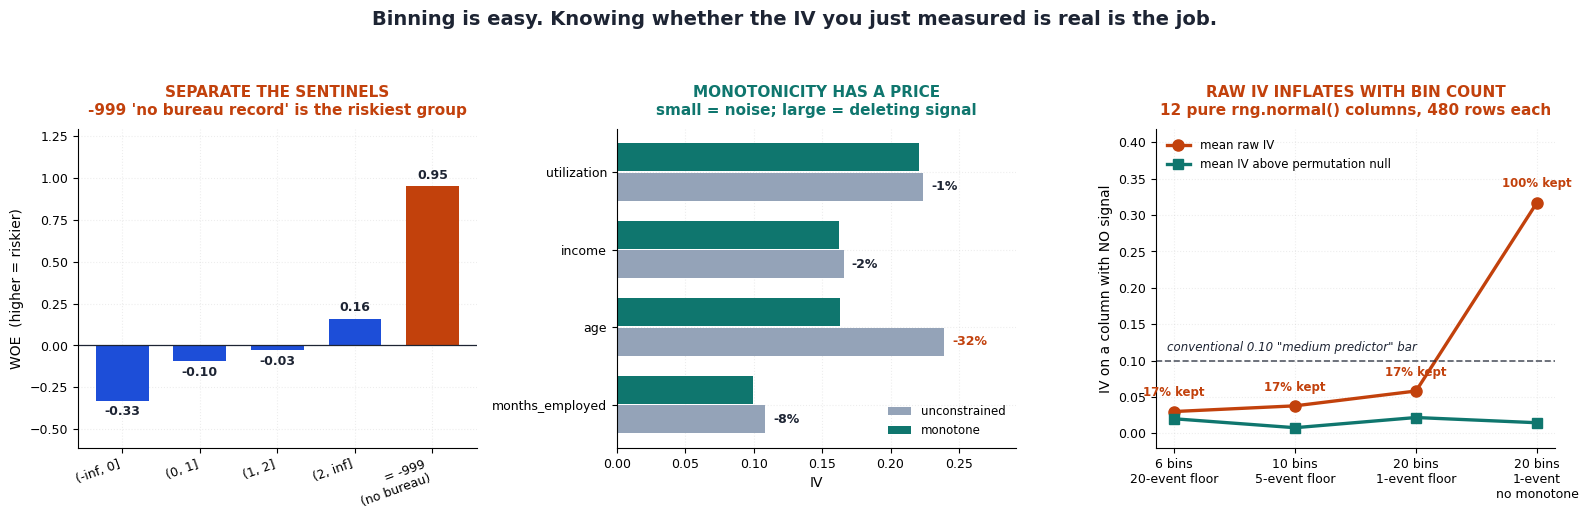

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

INK, GOOD, BAD, COOL, MUTED = "#1d2433", "#0f766e", "#c2410c", "#1d4ed8", "#94a3b8"

fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
fig.suptitle("Binning is easy. Knowing whether the IV you just measured is real is the job.",
             fontsize=14, fontweight="bold", color=INK, y=0.99)

ax = axes[0]
labels = [b.label.replace(" (special)", "\n(no bureau)") for b in ni.bins]
woes = [ni.woe(b) for b in ni.bins]
colors = [BAD if b.kind in (SPECIAL, MISSING) else COOL for b in ni.bins]
bars = ax.bar(range(len(woes)), woes, color=colors, width=0.68)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, fontweight="bold", color=INK)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8, rotation=20, ha="right")
ax.axhline(0, color=INK, linewidth=0.9)
ax.set_ylabel("WOE  (higher = riskier)")
ax.set_title("SEPARATE THE SENTINELS\n-999 'no bureau record' is the riskiest group",
             fontsize=11, color=BAD, fontweight="bold", pad=10)
ax.set_ylim(min(woes) - 0.28, max(woes) + 0.34)

ax = axes[1]
pairs = [(n, fit(F[n][tr], y[tr], monotone=False).iv, fit(F[n][tr], y[tr], monotone=True).iv)
         for n in ("utilization", "income", "age", "months_employed")]
pos = np.arange(len(pairs))
ax.barh(pos + 0.19, [p[1] for p in pairs], height=0.36, color=MUTED, label="unconstrained")
ax.barh(pos - 0.19, [p[2] for p in pairs], height=0.36, color=GOOD, label="monotone")
for i, (name, free, forced) in enumerate(pairs):
    pct = (free - forced) / free if free else 0
    ax.text(free + 0.006, i + 0.19, f"-{pct:.0%}", va="center", fontsize=9,
            fontweight="bold", color=BAD if pct > 0.15 else INK)
ax.set_yticks(pos); ax.set_yticklabels([p[0] for p in pairs], fontsize=9)
ax.set_xlabel("IV"); ax.set_xlim(0, max(p[1] for p in pairs) * 1.22)
ax.legend(fontsize=8.5, loc="lower right", frameon=False); ax.invert_yaxis()
ax.set_title("MONOTONICITY HAS A PRICE\nsmall = noise; large = deleting signal",
             fontsize=11, color=GOOD, fontweight="bold", pad=10)

ax = axes[2]
rows = noise_screen(ys[ts], n_columns=12, n_permutations=40)
xr = np.arange(len(rows))
ax.plot(xr, [r["mean_iv"] for r in rows], "o-", color=BAD, linewidth=2.4, markersize=8,
        label="mean raw IV")
ax.plot(xr, [r["mean_excess"] for r in rows], "s-", color=GOOD, linewidth=2.4, markersize=7,
        label="mean IV above permutation null")
ax.axhline(0.10, color=INK, linestyle="--", linewidth=1.2, alpha=0.75)
ax.text(-0.06, 0.113, 'conventional 0.10 "medium predictor" bar', fontsize=8.5,
        color=INK, style="italic")
for i, r in enumerate(rows):
    ax.annotate(f"{r['kept_by_iv']:.0%} kept", (i, r["mean_iv"]), textcoords="offset points",
                xytext=(0, 11), ha="center", fontsize=8.5, fontweight="bold", color=BAD)
ax.set_xticks(xr)
ax.set_xticklabels([str(r["settings"]).replace(", ", "\n") for r in rows], fontsize=8)
ax.set_ylabel("IV on a column with NO signal")
ax.set_ylim(-0.02, max(r["mean_iv"] for r in rows) * 1.32)
ax.legend(fontsize=8.5, loc="upper left", frameon=False)
ax.set_title("RAW IV INFLATES WITH BIN COUNT\n12 pure rng.normal() columns, 480 rows each",
             fontsize=11, color=BAD, fontweight="bold", pad=10)

for a in axes:
    for side in ("top", "right"):
        a.spines[side].set_visible(False)
    a.grid(alpha=0.22, linestyle=":"); a.set_axisbelow(True); a.tick_params(labelsize=9)

fig.tight_layout(rect=(0, 0.02, 1, 0.94))
plt.show()

## 9. So does any of this produce a better model?

Everything above is univariate. IV scores one column against the target and says nothing
about what happens when six of them go into one model together - so a screen that rejects
features is only worth having if what survives actually scores better on rows nobody fitted.

Three encodings of the same six columns, one holdout:

| arm | encoding |
|---|---|
| **A** | raw continuous, median-imputed, sentinel `-999` left in the column as a number |
| **B** | constrained WOE bins - size floors, monotone, missing and sentinel separated |
| **C** | loose WOE bins - 20 bins, 1-event floor, no monotonicity (the biggest-IV arm) |

If **C** wins the holdout, every constraint in this notebook is costing real accuracy and the
argument is decorative.

In [17]:
from downstream import format_lift, model_lift, robustness

rows = model_lift(data)
print(format_lift(rows))

arm                                 bins  total IV   AUC train  AUC holdout   gap
------------------------------------------------------------------------------
A raw continuous (median-imputed)      0      -        0.6983       0.7156  -0.0173
B constrained WOE bins                27    0.7536     0.7424       0.7317  +0.0107
C loose WOE bins                     108    0.9020     0.7637       0.7290  +0.0347


Read the two middle columns against the last one. **C** carries the most total IV and the
best training AUC, and lands *below* **B** on the holdout - its train-to-holdout gap is three
times as wide. IV ranks the arms in the opposite order to the thing anyone cares about.

**B** beating **A** is the part that justifies binning at all: same information, monotone and
reviewable, and about two AUC points better because the sentinel stopped being treated as the
number -999 and the missing rows stopped being median-imputed into a bin they do not belong in.

One split is not a finding, though. A 0.003 AUC gap between **B** and **C** is well inside the
noise of a single holdout - so run the whole thing again on ten independent datasets.

In [18]:
r = robustness()

print(f"mean holdout AUC   raw {r['auc_raw']:.4f}   "
      f"constrained {r['auc_constrained']:.4f}   loose {r['auc_loose']:.4f}\n")
print(f"constrained beats raw    {r['constrained_beats_raw']}/{r['n_seeds']} datasets  "
      f"(mean +{r['mean_margin_over_raw']:.4f} AUC)")
print(f"constrained beats loose  {r['constrained_beats_loose']}/{r['n_seeds']} datasets  "
      f"(mean +{r['mean_margin_over_loose']:.4f}, sd {r['sd_margin_over_loose']:.4f})")
print(f"\nloose carried more IV in every dataset: {r['loose_always_higher_iv']}")
print(f"mean overfit gap  loose {r['mean_gap_loose']:+.4f}  vs  "
      f"constrained {r['mean_gap_constrained']:+.4f}")

mean holdout AUC   raw 0.7021   constrained 0.7281   loose 0.7213

constrained beats raw    10/10 datasets  (mean +0.0260 AUC)
constrained beats loose  8/10 datasets  (mean +0.0067, sd 0.0064)

loose carried more IV in every dataset: True
mean overfit gap  loose +0.0374  vs  constrained +0.0121


So the honest version of the claim, with the part that does not replicate left in:

- Binning beats raw continuous **in all ten datasets**, by ~0.026 AUC. That one is solid.
- Constrained beats loose in **eight of ten**, mean +0.007 with an sd of the same size. Real,
  and small. Anyone reporting that as "constrained binning is more accurate" full stop is
  overreading a 0.007 margin.
- The loose arm carried more total IV in **ten of ten** and overfitted **three times harder**
  every time. *That* is the reliable finding - not that loose binning scores worse, but that its
  IV is systematically inflated while its holdout performance is not.

Which is the whole point: the constraints are not there to buy accuracy. They are there so the
number you report is the number you get.

## 10. Try your own feature

The engine takes plain numpy arrays. Three things are worth doing in order:

In [19]:
# ---------------------------------------------------------------------------------
# 1. Declare what is NOT a number. Sentinels are business logic - no algorithm
#    can infer that -999 means 'no bureau record' rather than 'minus 999'.
#
# my_x, my_y = your_frame["feature"].to_numpy(float), your_frame["target"].to_numpy(int)
# SENTINELS = (-999.0, -1.0, 0.0)          # whatever your source system uses
#
# 2. Fit with floors you can defend. min_bin_events is the single most important
#    parameter here - it is what stops IV becoming a smoothing artifact.
#
# scheme = fit(my_x, my_y, feature="feature",
#              max_bins=6,
#              min_bin_share=0.05,
#              min_bin_events=20,          # per bin, events AND non-events
#              smoothing=0.5,
#              monotone=True,
#              specials=SENTINELS)
# print(format_table(scheme))
#
# 3. Never quote the raw IV. Quote the excess over the permutation null, and check
#    the p-value before the feature goes anywhere near a scorecard.
#
# result = audit(x_train, y_train, x_holdout, y_holdout,
#                feature="feature", n_permutations=200, specials=SENTINELS)
# print(result.verdict, f"excess IV {result.excess_iv:.4f}, p={result.p_value:.3f}")
#
# if result.sparse_warning:
#     print("raise min_bin_events -", result.sparse_warning)
#
# # Read the monotonicity cost before accepting the shape.
# free = fit(x_train, y_train, monotone=False, specials=SENTINELS)
# if free.iv and (free.iv - result.iv_train) / free.iv > 0.15:
#     print("monotonicity is deleting real signal - consider splitting the feature")
#
# # Only then transform.
# X_model = scheme.transform(x_holdout)

---

**Streamlit version** - move the floors and the bin count, and watch the noise column climb
the IV bands while its p-value refuses to move:

```bash
pip install -r requirements.txt
streamlit run app.py
```

**Tests** - the guarantees, asserted (40 checks, including the false-positive rate):

```bash
python3 test_binning.py
```

One limitation worth stating: the permutation null costs a refit per permutation, so it is
cheap per feature and expensive across a thousand. Screen with a modest 40 permutations, then
re-run the survivors at 200+.

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) · [`ml-engineering-toolkit/feature-binner`](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/feature-binner)